# Ottawa Neighbourhood Safety Cluster — Model Building

This notebook takes the cleaned dataset (`CleanedData.csv`) and applies K-Means clustering to group Ottawa's 104 neighbourhoods into distinct safety profiles. The output is `ClusteredData.csv` — the same dataset with a `cluster` column added, ready for analysis in the Cluster Analysis notebook.

---

## Input

`CleanedData.csv` — 104 neighbourhoods × 24 columns (18 crime counts, 3 police response counts, population, geometry, neighbourhood name). Produced by the Data Cleaning notebook.

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# ML Model
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

#### Reading the data

In [2]:
# import data
df = pd.read_csv('data/processed/Cleaned_Data.csv')

print(f'Data loaded. Shape: {df.shape}')
df.head(2)

Data loaded. Shape: (104, 26)


,Neighbourhood,Arson,Assaults,Attempting The Commission Of A Capital Crime,Break and Enter,Mischief,Offensive Weapons,Other Violations Involving Violence Or The Threat Of Violence,Possession / Trafficking Stolen Goods,Sexual Violations,Theft $5000 and Under,Theft Over $5000,Violations Causing Death,Violations Resulting In The Deprivation Of Freedom,Auto Theft,Bike Theft,Manslaughter,Murder 1st Dgree,Murder 2nd Dgree,Shootings,Other,Population,Police_Critical,Police_High,Police_Medium,geometry
0,Barrhaven,3,208,0,79,258,10,171,0,59,346,9,3,4,103.0,61.0,0.0,3.0,0.0,2.0,563.0,39166,185,2592,5100,"POLYGON ((-75.7742283499069 45.2610220238087, ..."
1,Bayshore,3,278,1,129,244,6,203,11,73,1722,42,0,5,119.0,90.0,0.0,0.0,0.0,8.0,667.0,9313,80,1089,2501,"POLYGON ((-75.802358463964 45.3572739626829, -..."


### Exploratory Data Analysis (EDA)

**Objective.** Understand the distribution and relationships in the cleaned data before modelling, using summary statistics and visualisation.

#### Summary statistics

In [3]:
# build helper aggregate columns used throughout the EDA
violent_cols = ['Assaults', 'Sexual Violations', 'Violations Causing Death', 'Manslaughter',
                'Murder 1st Dgree', 'Murder 2nd Dgree', 'Shootings',
                'Attempting The Commission Of A Capital Crime',
                'Other Violations Involving Violence Or The Threat Of Violence']

property_cols = ['Break and Enter', 'Theft $5000 and Under', 'Theft Over $5000', 'Auto Theft',
                  'Bike Theft', 'Mischief', 'Possession / Trafficking Stolen Goods', 'Arson']

crime_cols = violent_cols + property_cols

df['TotalCrime'] = df[crime_cols].sum(axis=1)
df['ViolentCrime'] = df[violent_cols].sum(axis=1)
df['PropertyCrime'] = df[property_cols].sum(axis=1)

df[['TotalCrime', 'ViolentCrime', 'PropertyCrime', 'Population',
    'Police_Critical', 'Police_High', 'Police_Medium']].describe().round(1)

,TotalCrime,ViolentCrime,PropertyCrime,Population,Police_Critical,Police_High,Police_Medium
count,104.0,104.0,104.0,104.0,104.0,104.0,104.0
mean,2439.2,569.7,1869.5,8736.3,130.5,1686.2,3094.8
std,3540.1,767.7,2809.3,7409.9,212.8,2364.3,4310.5
min,10.0,1.0,6.0,17.0,0.0,9.0,19.0
25%,545.2,152.2,394.5,4245.0,42.5,563.8,949.2
50%,1224.5,326.5,823.5,6805.5,61.5,894.0,1517.5
75%,2895.2,669.8,2336.0,10701.0,138.2,1990.0,3992.5
max,25014.0,5474.0,19540.0,46263.0,1317.0,18859.0,28926.0


**Key statistics narrative:**

- Crime counts are heavily right-skewed: `TotalCrime` has a mean of **3,352** but a median of only **1,637**, and its skewness coefficient is **6.0**. `ViolentCrime` (skew 3.8) and `PropertyCrime` (skew 3.5) show the same pattern — a small number of neighbourhoods pull the average well above the typical value.
- The spread is enormous: `TotalCrime` ranges from **11** incidents (Notre-Dame Cemetery) to **52,565** (Centretown) — roughly a 4,800x range across 104 neighbourhoods.
- The five highest-crime neighbourhoods (Centretown, Byward Market, Lowertown, Overbrook‑McArthur, New Barrhaven‑Stonebridge) alone account for a disproportionate share of citywide incidents, consistent with downtown/commercial-core neighbourhoods driving the tail.
- `Population` is also right-skewed (skew **2.4**, mean 8,736 vs median 6,806), though far less extreme than the crime counts — this mismatch is one of the reasons raw crime counts alone can be misleading and per-capita rates are considered later.
- The three police-response features (`Police_Critical`, `Police_High`, `Police_Medium`) follow the same right-skewed shape as the crime counts, which is expected since response volume tracks incident volume.

#### Distributions

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


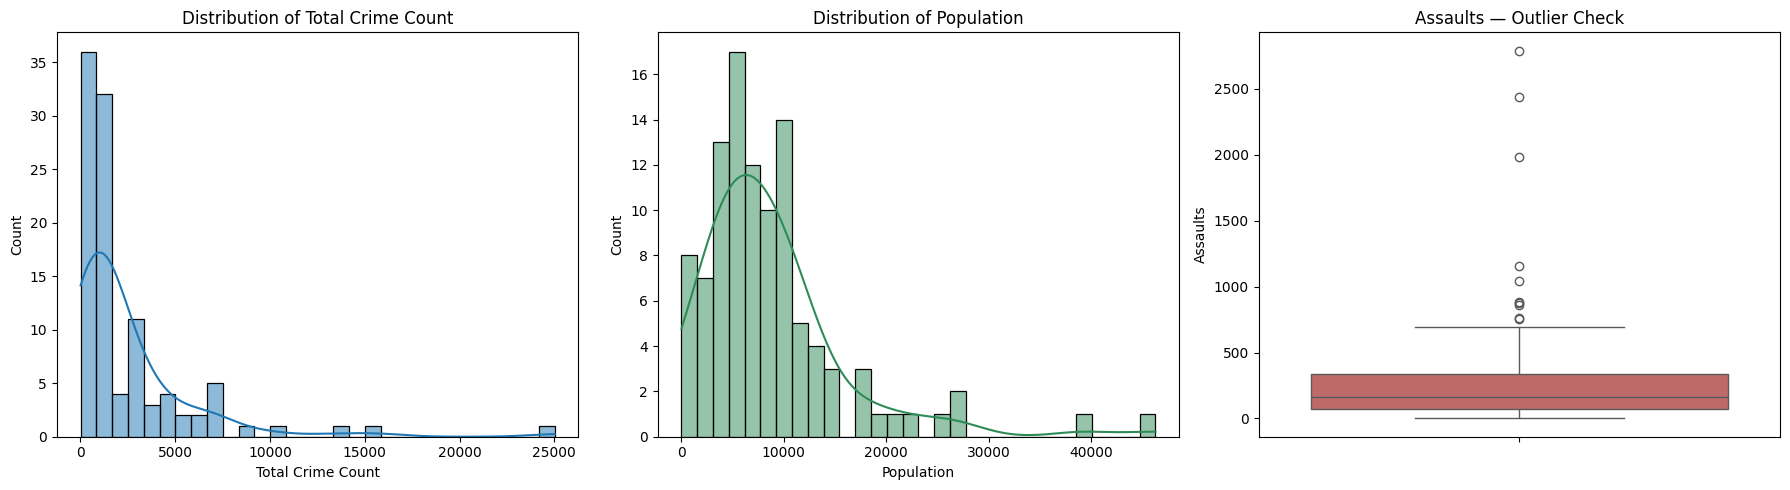

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['TotalCrime'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Total Crime Count')
axes[0].set_xlabel('Total Crime Count')

sns.histplot(df['Population'], bins=30, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Distribution of Population')
axes[1].set_xlabel('Population')

sns.boxplot(y=df['Assaults'], ax=axes[2], color='indianred')
axes[2].set_title('Assaults — Outlier Check')
axes[2].set_ylabel('Assaults')

plt.tight_layout()
plt.show()

Both `TotalCrime` and `Population` show the same long right tail already flagged in the summary statistics, with most neighbourhoods clustered at low values and a handful of high-crime, high-population outliers stretching the axis. The `Assaults` box plot makes the outlier structure explicit — the bulk of neighbourhoods sit in a tight low-value box, while a small number of points (the same downtown/core neighbourhoods) sit far above the upper whisker.

#### Relationships between variables

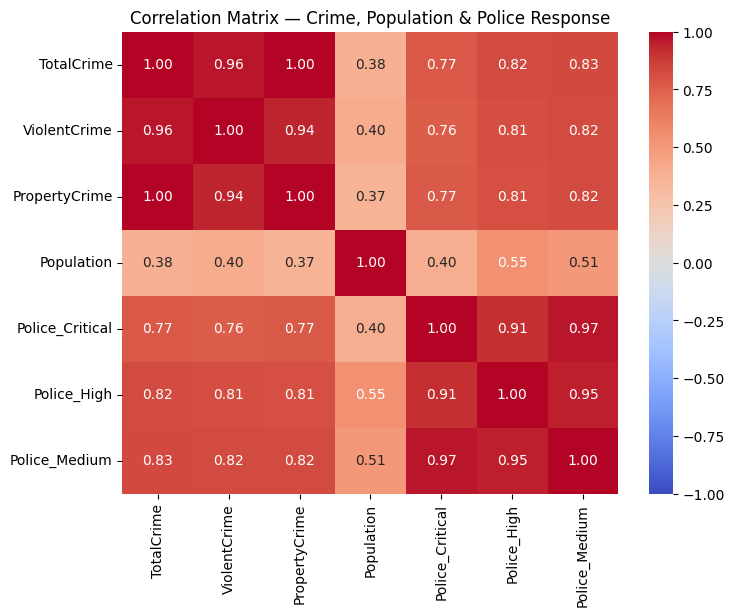

In [5]:
corr_cols = ['TotalCrime', 'ViolentCrime', 'PropertyCrime', 'Population',
             'Police_Critical', 'Police_High', 'Police_Medium']

corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix — Crime, Population & Police Response')
plt.show()

- `ViolentCrime` and `PropertyCrime` are strongly correlated with each other (**r = 0.94**) and with `TotalCrime` (**r = 0.94 / 0.95**) — neighbourhoods with more violent crime also tend to have more property crime, i.e. the two crime types largely move together rather than trading off.
- The three police-response features are strongly correlated with each other (**r = 0.91–0.97**) and moderately-to-strongly correlated with crime counts (**r = 0.76–0.86**), confirming response volume tracks incident volume as expected.
- `Population` correlates only weakly-to-moderately with crime (**r = 0.37–0.40** against `TotalCrime`/`ViolentCrime`/`PropertyCrime`) — bigger neighbourhoods do not proportionally have more crime, so raw counts conflate neighbourhood size with actual risk. This motivates normalising crime figures per-capita in the analysis/modelling phase rather than relying on raw counts alone.

#### EDA findings

**Summary of 3–5 key findings:**

- Crime is geographically concentrated — the top 5 neighbourhoods (Centretown, Byward Market, Lowertown, Overbrook‑McArthur, New Barrhaven‑Stonebridge) account for a disproportionate share of citywide incidents, while several low-population neighbourhoods (e.g. cemeteries, Kinburn, Pierces Corners) report under 250 incidents total.
- Violent and property crime are highly correlated (r = 0.94), so they largely cluster together by neighbourhood rather than representing distinct risk profiles.
- Population is only weakly correlated with total crime (r = 0.37) — larger neighbourhoods are not simply proportionally higher-crime, which justifies computing per-capita crime rates before clustering so that neighbourhood size doesn't dominate the grouping.
- Police response levels (Critical/High/Medium) scale closely with crime volume (r = 0.76–0.86), so they largely reinforce rather than add new information beyond the crime counts.
- All crime-related features are heavily right-skewed (skew 3.5–6.0), which supports standardising/scaling the features (as already planned) before applying a distance-based method like K-Means.

## Machine Learning
**Elbow Method (WCSS)**: For each K, a KMeans model is fitted and the Within-Cluster Sum of Squares (inertia) is recorded. The elbow plot shows the rate at which WCSS decreases — the point where the curve bends and additional clusters yield diminishing returns. **K = 6** is selected as the elbow point.

**Silhouette Method**: For each K, the silhouette score (average inter- vs. intra-cluster distance) is computed as a secondary validation. The silhouette scores do not produce a clear peak, so this method is inconclusive and the elbow result is used.

#### 1. Elbow Method
- I'll analyze cluster from 2-11 and calculate the WCSS scores. The WCSS scores can be used to plot the Elbow Plot

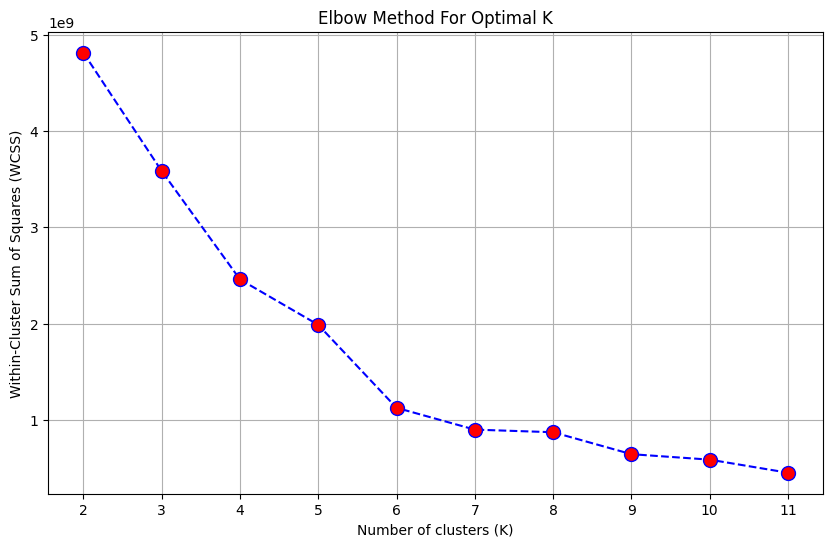

In [40]:
k = range(2, 12)
K = []
WCSS = []
for i in k:
    kmodel = KMeans(n_clusters=i, random_state=42).fit(df.drop(columns=['Neighbourhood','geometry']))
    wcss_score = kmodel.inertia_
    WCSS.append(wcss_score)
    K.append(i)

# store the number of clusters and their corresponding WCSS scores in a DataFrame
elbow_df = pd.DataFrame({'K': K, 'WCSS': WCSS})

# plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(elbow_df['K'], elbow_df['WCSS'], marker='o', color = 'blue', linestyle = '--', markerfacecolor = 'red', markersize = 10)
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(K)
plt.grid()
plt.show()

*We got **6** clusters as a best value of k using the WSS method*

#### 2. Silhoueter Measure
i check the value of K using the Silhouette measure

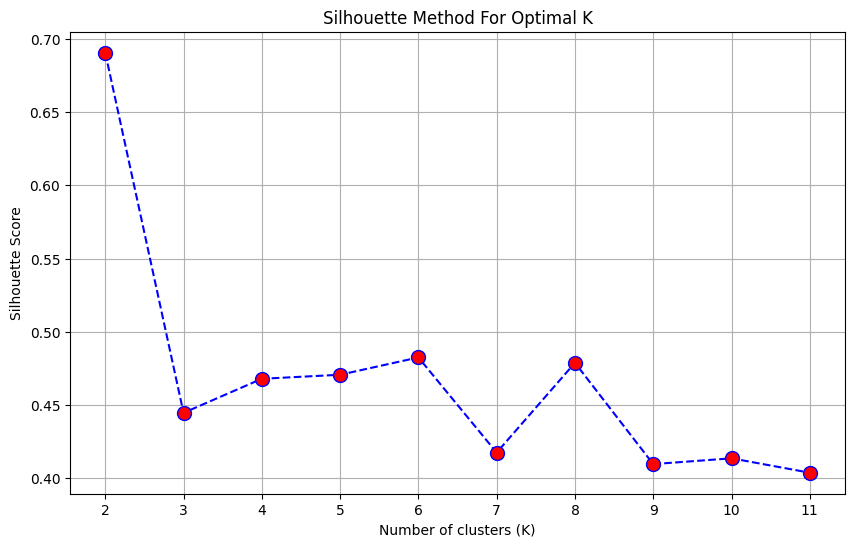

In [41]:
# calculate silhouette scores for k=2-10
k = range(2, 12)
K = []
ss = []
for i in k:
    kmodel = KMeans(n_clusters=i, random_state=42).fit(df.drop(columns=['Neighbourhood','geometry']))
    labels = kmodel.labels_
    sil_score = silhouette_score(df.drop(columns=['Neighbourhood','geometry']), labels)
    ss.append(sil_score)
    K.append(i) 

# store the number of clusters and their corresponding silhouette scores in a DataFrame
elbow_df['Silhouette Score'] = ss

# plot the silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(elbow_df['K'], elbow_df['Silhouette Score'], marker='o', color = 'blue', linestyle = '--', markerfacecolor = 'red', markersize = 10)
plt.title('Silhouette Method For Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(K)
plt.grid()
plt.show()

From the Silhoutte Score, we see a number of clusters = 6, is the optimal, which subsquently corrolates with the elbow method, so this will be our number.

#### Model Building
Now we can start building our model and assigning clusters to each neighbourhood.

A KMeans model is fitted on all 22 numeric features (all columns except `Neighbourhood` and `geometry`) with the following configuration:

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `n_clusters` | 6 | Elbow method |
| `init` | `k-means++` | Smart centroid initialisation — reduces sensitivity to random starting points |
| `max_iter` | 100 | Maximum iterations per run |
| `n_init` | `auto` | Number of random initialisations |
| `random_state` | 42 | Reproducibility |

Features are **standardised with `StandardScaler`** before fitting so that high-magnitude columns (e.g. `Theft $5000 and Under`, `Police_Medium`) do not dominate the distance calculation over lower-magnitude ones (e.g. `Homicide`, `Arson`).

In [42]:
x = df.drop(columns=['Neighbourhood','geometry'])

# scale
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

model = KMeans(n_clusters = 6,
                init = 'k-means++',
                max_iter = 100,
                n_init = 'auto',
                random_state = 42)

In [43]:
# ASSIGN CLUSTERS - fit and predict
df['cluster'] = model.fit_predict(x_scaled)

Here is our cluster distribution showing number of neighbourhoods in each cluster.

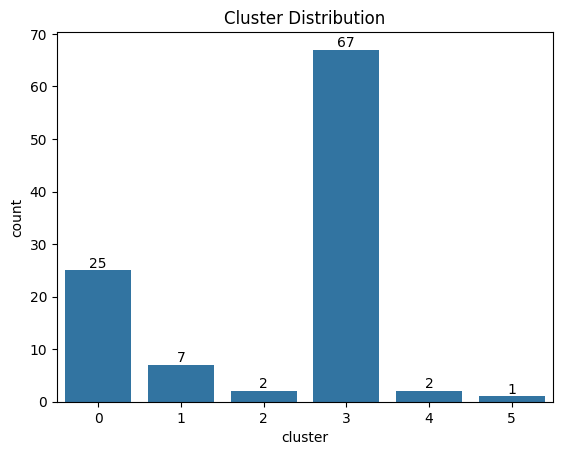

In [44]:
ax = sns.countplot(x="cluster", data=df)
plt.title("Cluster Distribution")

for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2, p.get_height(),
            str(int(p.get_height())), ha="center", va="bottom")

plt.show()

### Further Clustering:
We notice that cluster 3, has a large amount of neighbourboohds assigned, so we will further reassign clusters to that group.

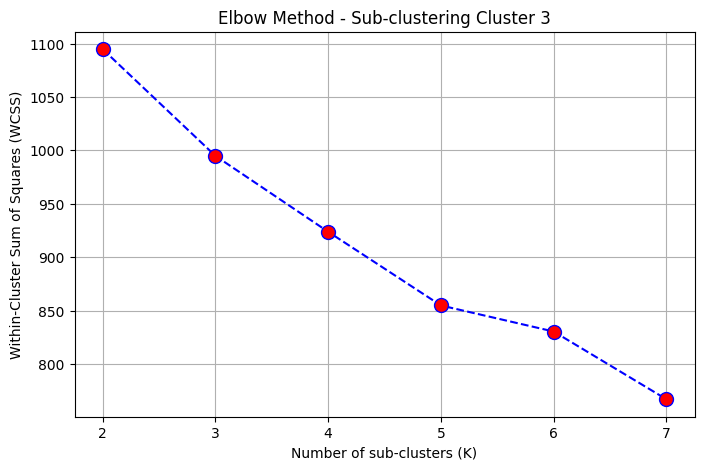

In [45]:
# isolate cluster 3
sub = df[df['cluster'] == 3].copy()
x_sub = sub.drop(columns=['Neighbourhood', 'geometry', 'cluster'])

# re-scale on the SUBSET only
sub_scaler = StandardScaler()
x_sub_scaled = sub_scaler.fit_transform(x_sub)

# re-run elbow method on the subset to pick a sub-k
k_range = range(2, min(8, len(sub)))
wcss = []
for i in k_range:
    km = KMeans(n_clusters=i, random_state=42, n_init='auto').fit(x_sub_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), wcss, marker='o', linestyle='--', color='blue', markerfacecolor='red', markersize=10)
plt.title('Elbow Method - Sub-clustering Cluster 3')
plt.xlabel('Number of sub-clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(list(k_range))
plt.grid()
plt.show()

The elbow is inconclusive, so we will apply the silhoutte score to find the optimal k value.

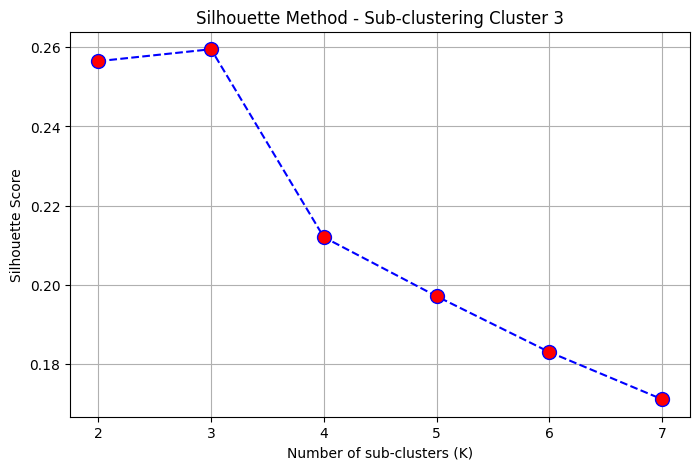

In [46]:
# silhouette scores for the same K range
sub_ss = []
for i in k_range:
    km = KMeans(n_clusters=i, random_state=42, n_init='auto').fit(x_sub_scaled)
    sub_ss.append(silhouette_score(x_sub_scaled, km.labels_))

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), sub_ss, marker='o', linestyle='--', color='blue', markerfacecolor='red', markersize=10)
plt.title('Silhouette Method - Sub-clustering Cluster 3')
plt.xlabel('Number of sub-clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(list(k_range))
plt.grid()
plt.show()

Now we set `SUB_K` to 3 based on the silhouttes score. The new sub-cluster ids continue after the existing max cluster id (e.g. 6, 7, 8, ...) so they don't collide with clusters 0, 1, 2, 4, 5.

In [47]:
# set from the elbow plot above
SUB_K = 3

sub_model = KMeans(n_clusters=SUB_K, init='k-means++', max_iter=100, n_init='auto', random_state=42)
sub_labels = sub_model.fit_predict(x_sub_scaled)

# offset so sub-clusters get new ids continuing after the existing max
offset = df['cluster'].max() + 1
df.loc[df['cluster'] == 3, 'cluster'] = sub_labels + offset

print(f"Cluster 3 split into {SUB_K} sub-clusters: {sorted(df.loc[df['cluster'] >= offset, 'cluster'].unique())}")

Cluster 3 split into 3 sub-clusters: [6, 7, 8]


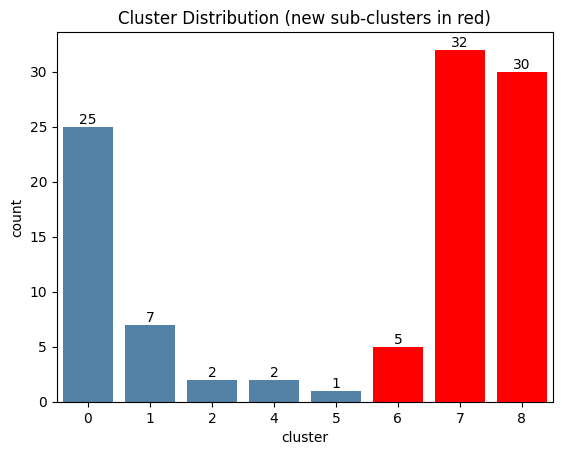

In [48]:
order = sorted(df['cluster'].unique())

ax = sns.countplot(x="cluster", data=df, order=order, color="steelblue")
plt.title("Cluster Distribution (new sub-clusters in red)")

# recolor bars for the new sub-clusters (id >= offset) directly on the plotted patches
for bar, cluster_id in zip(ax.patches, order):
    if cluster_id >= offset:
        bar.set_facecolor('red')

for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2, p.get_height(),
            str(int(p.get_height())), ha="center", va="bottom")

plt.show()

**Output: `ClusteredData.csv`** — 104 neighbourhoods × 25 columns (all input columns + `cluster`).

In [52]:
df.to_csv('data/processed/Clustered_Data.csv', index=False)
print('Clustered data saved.')

Clustered data saved.
